# Initialization

In [23]:
# Env Dependencies
!pip install -q gymnasium[atari] ale-py torch tensorboard tyro

import gymnasium as gym
import ale_py
gym.register_envs(ale_py)

In [24]:
import os
import random
import time
from dataclasses import dataclass

import gymnasium as gym
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import tyro
from torch.distributions.categorical import Categorical
from torch.utils.tensorboard import SummaryWriter

In [25]:
# # Verifying environment works
# import gymnasium as gym
# import ale_py
# gym.register_envs(ale_py)

# env = gym.make("PongNoFrameskip-v4")
# print(f"Obs shape: {env.observation_space.shape}")
# print(f"Actions: {env.action_space.n}")
# print(f"Action meanings: {env.unwrapped.get_action_meanings()}")

# CleanRL Implementation

In [26]:
# Config
config = {
    # Experiment
    "env_id": "PongNoFrameskip-v4",
    "seed": 0,
    "total_timesteps": 2_000_000,
    
    # Environment
    "num_envs": 8,
    
    # PPO
    "learning_rate": 1e-3,      
    "num_steps": 128,           # steps per env per rollout
    "gamma": 0.99,              # discount factor
    "gae_lambda": 0.95,         # GAE parameter
    "num_minibatches": 4,       # split batch into 4 minibatches
    "update_epochs": 4,         # train on each batch 4 times
    "clip_coef": 0.2,           # PPO clip range
    "ent_coef": 0.01,           # entropy bonus weight
    "vf_coef": 0.5,             # value loss weight
    "max_grad_norm": 0.5,       # gradient clipping
    "anneal_lr": True,          # decay learning rate to 0
    
    # Derived (don't change these)
    "batch_size": 0,
    "minibatch_size": 0,
    "num_iterations": 0,
}

In [27]:
# Environment
!mkdir -p cleanrl_utils
!wget -q https://raw.githubusercontent.com/vwxyzjn/cleanrl/master/cleanrl_utils/atari_wrappers.py -O cleanrl_utils/atari_wrappers.py
!touch cleanrl_utils/__init__.py

from cleanrl_utils.atari_wrappers import (
    ClipRewardEnv,
    EpisodicLifeEnv,
    FireResetEnv,
    MaxAndSkipEnv,
    NoopResetEnv,
)

def make_env(env_id, idx):
    def thunk():
        env = gym.make(env_id)
        env = gym.wrappers.RecordEpisodeStatistics(env)
        env = NoopResetEnv(env, noop_max=30)
        env = MaxAndSkipEnv(env, skip=4)
        env = EpisodicLifeEnv(env)
        if "FIRE" in env.unwrapped.get_action_meanings():
            env = FireResetEnv(env)
        env = ClipRewardEnv(env)
        env = gym.wrappers.ResizeObservation(env, (84, 84))
        env = gym.wrappers.GrayscaleObservation(env)
        env = gym.wrappers.FrameStackObservation(env, 4)
        return env
    return thunk

In [28]:
# Agent (NatureCNN)
def layer_init(layer, std=np.sqrt(2), bias_const=0.0):
    torch.nn.init.orthogonal_(layer.weight, std)
    torch.nn.init.constant_(layer.bias, bias_const)
    return layer

class Agent(nn.Module):
    def __init__(self, envs=None, num_actions=6):
        if envs is not None:
            num_actions = envs.single_action_space.n
        super().__init__()
        self.network = nn.Sequential(
            layer_init(nn.Conv2d(4, 32, 8, stride=4)),
            nn.ReLU(),
            layer_init(nn.Conv2d(32, 64, 4, stride=2)),
            nn.ReLU(),
            layer_init(nn.Conv2d(64, 64, 3, stride=1)),
            nn.ReLU(),
            nn.Flatten(),
            layer_init(nn.Linear(64 * 7 * 7, 512)),
            nn.ReLU(),
        )
        self.actor = layer_init(nn.Linear(512, num_actions), std=0.01)
        self.critic = layer_init(nn.Linear(512, 1), std=1)

    def get_value(self, x):
        return self.critic(self.network(x / 255.0))

    def get_action_and_value(self, x, action=None):
        hidden = self.network(x / 255.0)
        logits = self.actor(hidden)
        probs = Categorical(logits=logits)
        if action is None:
            action = probs.sample()
        return action, probs.log_prob(action), probs.entropy(), self.critic(hidden)

In [29]:
# Seed Setting Function
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = False

In [30]:
# Training function
def train(config):
    seed = config["seed"]
    run_name = f"{config['env_id']}__E1__{seed}__{int(time.time())}"
    config["batch_size"] = config["num_envs"] * config["num_steps"]
    config["minibatch_size"] = config["batch_size"] // config["num_minibatches"]
    config["num_iterations"] = config["total_timesteps"] // config["batch_size"]
    
    # --- Logging setup ---
    writer = SummaryWriter(f"runs/{run_name}")
    writer.add_text("hyperparameters",
        "|param|value|\n|-|-|\n%s" % ("\n".join([f"|{key}|{value}|" for key, value in config.items()])),
    )

    # --- Seeding ---
    set_seed(seed)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # --- Environment setup ---
    envs = gym.vector.SyncVectorEnv(
        [make_env(config["env_id"], i) for i in range(config["num_envs"])]
    )
    
    # --- Agent and optimizer ---
    agent = Agent(envs).to(device)
    optimizer = optim.Adam(agent.parameters(), lr=config["learning_rate"], eps=1e-5)
    
    # --- Storage (pre-allocate tensors for rollout data) ---
    obs = torch.zeros((config["num_steps"], config["num_envs"]) + envs.single_observation_space.shape).to(device)
    actions = torch.zeros((config["num_steps"], config["num_envs"]) + envs.single_action_space.shape).to(device)
    logprobs = torch.zeros((config["num_steps"], config["num_envs"])).to(device)
    rewards = torch.zeros((config["num_steps"], config["num_envs"])).to(device)
    dones = torch.zeros((config["num_steps"], config["num_envs"])).to(device)
    values = torch.zeros((config["num_steps"], config["num_envs"])).to(device)
    
    # --- Start the game ---
    global_step = 0
    start_time = time.time()
    next_obs, _ = envs.reset(seed=seed)
    next_obs = torch.Tensor(next_obs).to(device)
    next_done = torch.zeros(config["num_envs"]).to(device)

    num_iterations = config["num_iterations"]
        
    for iteration in range(1, config["num_iterations"] + 1):
        
        # --- Learning rate annealing ---
        if config["anneal_lr"]:
            frac = 1.0 - (iteration - 1.0) / num_iterations
            lrnow = frac * config["learning_rate"]
            optimizer.param_groups[0]["lr"] = lrnow
        
        # ==========================================
        # PHASE 1: Collect experience (rollout)
        # ==========================================
        for step in range(0, config["num_steps"]):
            global_step += config["num_envs"]
            obs[step] = next_obs
            dones[step] = next_done

            # Action Logic
            with torch.no_grad():
                action, logprob, _, value = agent.get_action_and_value(next_obs)
                values[step] = value.flatten()
            actions[step] = action
            logprobs[step] = logprob
            
            next_obs, reward, terminations, truncations, infos = envs.step(action.cpu().numpy())
            next_done = np.logical_or(terminations, truncations)
            rewards[step] = torch.tensor(reward).to(device).view(-1)
            next_obs, next_done = torch.Tensor(next_obs).to(device), torch.Tensor(next_done).to(device)
            
            # Log episode returns
            if "episode" in infos and any(infos.get("_episode", [])):
                for i, done in enumerate(infos.get("_episode", [])):
                    if done:
                        ep_return = infos["episode"]["r"][i]
                        ep_length = infos["episode"]["l"][i]
                        print(f"global_step={global_step}, episodic_return={ep_return}")
                        writer.add_scalar("charts/episodic_return", ep_return, global_step)
                        writer.add_scalar("charts/episodic_length", ep_length, global_step)
        
        # ==========================================
        # PHASE 2: Compute advantages (GAE)
        # ==========================================
        with torch.no_grad():
            next_value = agent.get_value(next_obs).reshape(1, -1)
            advantages = torch.zeros_like(rewards).to(device)
            lastgaelam = 0
            for t in reversed(range(config["num_steps"])):
                if t == config["num_steps"] - 1:
                    nextnonterminal = 1.0 - next_done
                    nextvalues = next_value
                else:
                    nextnonterminal = 1.0 - dones[t + 1]
                    nextvalues = values[t + 1]
                delta = rewards[t] + config["gamma"] * nextvalues * nextnonterminal - values[t]
                advantages[t] = lastgaelam = delta + config["gamma"] * config["gae_lambda"] * nextnonterminal * lastgaelam
            returns = advantages + values
        
        # Flatten the batch
        b_obs = obs.reshape((-1,) + envs.single_observation_space.shape)
        b_logprobs = logprobs.reshape(-1)
        b_actions = actions.reshape((-1,) + envs.single_action_space.shape)
        b_advantages = advantages.reshape(-1)
        b_returns = returns.reshape(-1)
        b_values = values.reshape(-1)
        
        # ==========================================
        # PHASE 3: Update policy and value network
        # ==========================================
        b_inds = np.arange(config["batch_size"])
        clipfracs = []
        
        for epoch in range(config["update_epochs"]):
            np.random.shuffle(b_inds)
            for start in range(0, config["batch_size"], config["minibatch_size"]):
                end = start + config["minibatch_size"]
                mb_inds = b_inds[start:end]
                
                _, newlogprob, entropy, newvalue = agent.get_action_and_value(
                    b_obs[mb_inds], b_actions.long()[mb_inds]
                )
                logratio = newlogprob - b_logprobs[mb_inds]
                ratio = logratio.exp()
                
                with torch.no_grad():
                    old_approx_kl = (-logratio).mean()
                    approx_kl = ((ratio - 1) - logratio).mean()
                    clipfracs += [((ratio - 1.0).abs() > config["clip_coef"]).float().mean().item()]
                
                # Normalize advantages
                mb_advantages = b_advantages[mb_inds]
                mb_advantages = (mb_advantages - mb_advantages.mean()) / (mb_advantages.std() + 1e-8)
                
                # Policy loss (clipped)
                pg_loss1 = -mb_advantages * ratio
                pg_loss2 = -mb_advantages * torch.clamp(ratio, 1 - config["clip_coef"], 1 + config["clip_coef"])
                pg_loss = torch.max(pg_loss1, pg_loss2).mean()
                
                # Value loss (clipped)
                newvalue = newvalue.view(-1)
                v_loss_unclipped = (newvalue - b_returns[mb_inds]) ** 2
                v_clipped = b_values[mb_inds] + torch.clamp(
                    newvalue - b_values[mb_inds], -config["clip_coef"], config["clip_coef"]
                )
                v_loss_clipped = (v_clipped - b_returns[mb_inds]) ** 2
                v_loss = 0.5 * torch.max(v_loss_unclipped, v_loss_clipped).mean()
                
                entropy_loss = entropy.mean()# Entropy loss
                # Total loss
                loss = pg_loss - config["ent_coef"] * entropy_loss + config["vf_coef"] * v_loss
                
                optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(agent.parameters(), config["max_grad_norm"])
                optimizer.step()
            
            if config.get("target_kl") and approx_kl > config["target_kl"]:
                break
        
        # ==========================================
        # PHASE 4: Logging
        # ==========================================
        y_pred, y_true = b_values.cpu().numpy(), b_returns.cpu().numpy()
        var_y = np.var(y_true)
        explained_var = np.nan if var_y == 0 else 1 - np.var(y_true - y_pred) / var_y
        
        writer.add_scalar("charts/learning_rate", optimizer.param_groups[0]["lr"], global_step)
        writer.add_scalar("losses/value_loss", v_loss.item(), global_step)
        writer.add_scalar("losses/policy_loss", pg_loss.item(), global_step)
        writer.add_scalar("losses/entropy", entropy_loss.item(), global_step)
        writer.add_scalar("losses/old_approx_kl", old_approx_kl.item(), global_step)
        writer.add_scalar("losses/approx_kl", approx_kl.item(), global_step)
        writer.add_scalar("losses/clipfrac", np.mean(clipfracs), global_step)
        writer.add_scalar("losses/explained_variance", explained_var, global_step)
        # print("SPS:", int(global_step / (time.time() - start_time)))
        if iteration % 100 == 0:
            print(f"iteration={iteration}/{num_iterations}, global_step={global_step}, "
                  f"SPS={int(global_step / (time.time() - start_time))}")

        writer.add_scalar("charts/SPS", int(global_step / (time.time() - start_time)), global_step)

        
        # Save checkpoint every 500K steps
        if global_step % 500000 < config["batch_size"]:
            torch.save({
                "agent": agent.state_dict(),
                "global_step": global_step,
                "seed": seed,
            }, f"runs/{run_name}/checkpoint_{global_step}_Seed{seed}.pt")
            print(f"Saved checkpoint model at step {global_step}")
    
    # Save final model
    torch.save({
        "agent": agent.state_dict(),
        "global_step": global_step,
        "seed": seed,
    }, f"runs/{run_name}/final_model_Seed{seed}.pt")
    print(f"Saved final model at step {global_step}")
    
    envs.close()
    writer.close()
    return run_name

# Training

In [31]:
# # training test
# config["total_timesteps"] = 100_000
# config["seed"]
# run_name = train(config)

In [32]:
# # Hyperparameter sweep
hp_sweep = False
if hp_sweep:
    # Sweep run 1: LR=1e-4, clip=0.1
    config["seed"] = 42
    config["total_timesteps"] = 1_000_000
    config["learning_rate"] = 1e-4
    config["clip_coef"] = 0.1
    run_name = train(config)
    
    # Sweep run 2: LR=1e-4, clip=0.2
    config["seed"] = 42
    config["total_timesteps"] = 1_000_000
    config["learning_rate"] = 1e-4
    config["clip_coef"] = 0.2
    run_name = train(config)
    
    # Sweep run 3: LR=2.5e-4, clip=0.1
    config["seed"] = 42
    config["total_timesteps"] = 1_000_000
    config["learning_rate"] = 2.5e-4
    config["clip_coef"] = 0.1
    run_name = train(config)
    
    # Sweep run 4: LR=2.5e-4, clip=0.2
    config["seed"] = 42
    config["total_timesteps"] = 1_000_000
    config["learning_rate"] = 2.5e-4
    config["clip_coef"] = 0.2
    run_name = train(config)
    
    # Sweep run 5: LR=1e-3, clip=0.1
    config["seed"] = 42
    config["total_timesteps"] = 1_000_000
    config["learning_rate"] = 1e-3
    config["clip_coef"] = 0.1
    run_name = train(config)
    
    # Sweep run 6: LR=1e-3, clip=0.2
    config["seed"] = 42
    config["total_timesteps"] = 1_000_000
    config["learning_rate"] = 1e-3
    config["clip_coef"] = 0.2
    run_name = train(config)

In [33]:
# best hp:LR=1e-3, clip=0.2
config["learning_rate"] = 1e-3
config["clip_coef"] = 0.2

# # Seed 0: 
# config["seed"] = 0
# config["total_timesteps"] = 2_000_000
# run_name = train(config)

# # Seed 1: 
# config["seed"] = 1
# config["total_timesteps"] = 2_000_000
# run_name = train(config)

# # Seed 2: 
# config["seed"] = 2
# config["total_timesteps"] = 2_000_000
# run_name = train(config)

# Seed 3: 
config["seed"] = 3
config["total_timesteps"] = 2_000_000
run_name = train(config)

# Seed 4: 
config["seed"] = 4
config["total_timesteps"] = 2_000_000
run_name = train(config)

A.L.E: Arcade Learning Environment (version 0.11.2+ecc1138)
[Powered by Stella]


global_step=6776, episodic_return=-21.0
global_step=6888, episodic_return=-20.0
global_step=6904, episodic_return=-21.0
global_step=6912, episodic_return=-21.0
global_step=7424, episodic_return=-20.0
global_step=7952, episodic_return=-19.0
global_step=8064, episodic_return=-20.0
global_step=8624, episodic_return=-20.0
global_step=13560, episodic_return=-20.0
global_step=13928, episodic_return=-20.0
global_step=13968, episodic_return=-20.0
global_step=14768, episodic_return=-21.0
global_step=14800, episodic_return=-20.0
global_step=15096, episodic_return=-20.0
global_step=15104, episodic_return=-21.0
global_step=16304, episodic_return=-21.0
global_step=20736, episodic_return=-21.0
global_step=20984, episodic_return=-21.0
global_step=21760, episodic_return=-20.0
global_step=21928, episodic_return=-20.0
global_step=22472, episodic_return=-19.0
global_step=22648, episodic_return=-21.0
global_step=23112, episodic_return=-20.0
global_step=24568, episodic_return=-20.0
global_step=27696, episo

# Validation

In [34]:
# HyperParameter Learning Curve Plot
if hp_sweep:
    !pip install -q tbparse
    from tbparse import SummaryReader
    import matplotlib.pyplot as plt
    import os
    
    data_dir = '/kaggle/input/datasets/yusufhilalll/e1-hpsweep'
    
    # Map sweep numbers to hyperparameters
    sweep_configs = {
        "Sweep1": "LR=1e-4, clip=0.1",
        "Sweep2": "LR=1e-4, clip=0.2",
        "Sweep3": "LR=2.5e-4, clip=0.1",
        "Sweep4": "LR=2.5e-4, clip=0.2",
        "Sweep5": "LR=1e-3, clip=0.1",
        "Sweep6": "LR=1e-3, clip=0.2",
    }
    
    # Find all tfevents files
    tf_files = sorted([f for f in os.listdir(data_dir) if 'events' in f])
    
    plt.figure(figsize=(12, 6))
    
    print(f"{'Sweep':<10} {'Config':<25} {'Best':>8} {'Final Mean':>12}")
    print("-" * 55)
    
    for tf_file in tf_files:
        sweep_name = tf_file.split('_events')[0]  # e.g. "Sweep1"
        label = sweep_configs.get(sweep_name, sweep_name)
        
        reader = SummaryReader(os.path.join(data_dir, tf_file))
        df = reader.scalars
        returns = df[df['tag'] == 'charts/episodic_return']
        
        if len(returns) == 0:
            print(f"{sweep_name:<10} {label:<25} NO DATA")
            continue
        
        smoothed = returns['value'].rolling(window=20, min_periods=1).mean()
        plt.plot(returns['step'], smoothed, label=label, linewidth=1.5)
        
        best = returns['value'].max()
        final = returns['value'].tail(10).mean()
        print(f"{sweep_name:<10} {label:<25} {best:>8.1f} {final:>12.1f}")
    
    plt.xlabel('Steps')
    plt.ylabel('Episodic Return')
    plt.title('E1 Hyperparameter Sweep (seed 42, 1M steps)')
    plt.axhline(y=-20.5, color='gray', linestyle='--', alpha=0.5)
    plt.legend()
    plt.tight_layout()
    plt.savefig('e1_hp_sweep.png', dpi=150)
    plt.show()

In [35]:
# Hyperparameter evaluation
if hp_sweep:
    def evaluate_model(model_path, num_episodes=20):
        agent = Agent()
        checkpoint = torch.load(model_path, map_location='cpu')
        agent.load_state_dict(checkpoint['agent'])
        agent.eval()
        
        env = make_env(config["env_id"], 0)()
        returns = []
        
        for ep in range(num_episodes):
            obs, _ = env.reset(seed=ep)
            total_reward = 0
            done = False
            while not done:
                obs_tensor = torch.tensor(np.array(obs), dtype=torch.float32).unsqueeze(0)
                with torch.no_grad():
                    action, _, _, _ = agent.get_action_and_value(obs_tensor)
                obs, reward, term, trunc, _ = env.step(action.item())
                total_reward += reward
                done = term or trunc
            returns.append(total_reward)
        
        env.close()
        return np.mean(returns), np.std(returns) / np.sqrt(len(returns))
    
    # Evaluate all sweeps
    data_dir = '/kaggle/input/datasets/yusufhilalll/e1-hpsweep'
    
    sweep_configs = {
        "Sweep1": "LR=1e-4, clip=0.1",
        "Sweep2": "LR=1e-4, clip=0.2",
        "Sweep3": "LR=2.5e-4, clip=0.1",
        "Sweep4": "LR=2.5e-4, clip=0.2",
        "Sweep5": "LR=1e-3, clip=0.1",
        "Sweep6": "LR=1e-3, clip=0.2",
    }
    
    print(f"{'Sweep':<10} {'Config':<25} {'Mean':>8} {'± SE':>8}")
    print("-" * 55)
    
    for i in range(1, 7):
        path = f"{data_dir}/Sweep{i}_final_model.pt"
        if os.path.exists(path):
            mean, se = evaluate_model(path)
            print(f"Sweep{i:<5} {sweep_configs[f'Sweep{i}']:<25} {mean:>8.1f} {se:>8.1f}")
        else:
            print(f"Sweep{i:<5} {sweep_configs[f'Sweep{i}']:<25} FILE NOT FOUND")

Reading: runs/PongNoFrameskip-v4__E1__4__1774977208


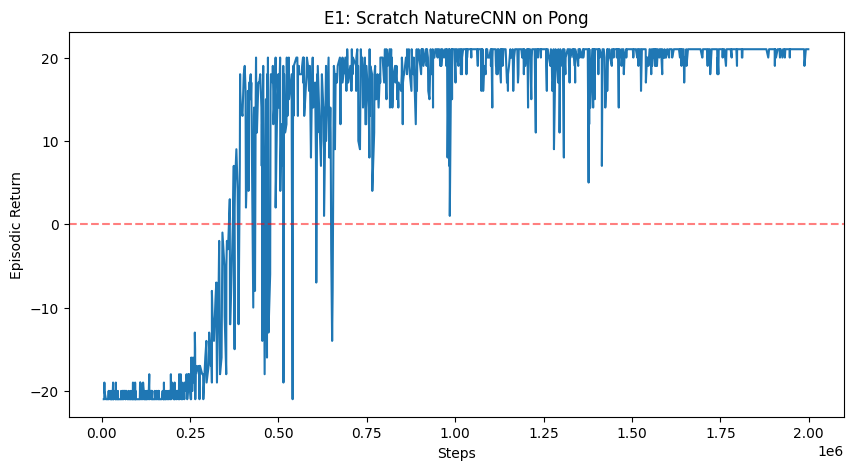


Best return: 21.0
Final return: 21.0


In [36]:
# Cell 5: Parse and plot results
!pip install -q tbparse matplotlib

from tbparse import SummaryReader
import matplotlib.pyplot as plt

# Find latest run
import os
runs = sorted([d for d in os.listdir('runs') if d.startswith('PongNoFrameskip-v4__E1')])
latest = f'runs/{runs[-1]}'
print(f"Reading: {latest}")

reader = SummaryReader(latest)
df = reader.scalars

# Plot episodic returns
returns = df[df['tag'] == 'charts/episodic_return']
plt.figure(figsize=(10, 5))
plt.plot(returns['step'], returns['value'])
plt.xlabel('Steps')
plt.ylabel('Episodic Return')
plt.title('E1: Scratch NatureCNN on Pong')
plt.axhline(y=0, color='r', linestyle='--', alpha=0.5)
plt.savefig('e1_learning_curve.png', dpi=150)
plt.show()

print(f"\nBest return: {returns['value'].max()}")
print(f"Final return: {returns['value'].iloc[-1]}")

['charts/SPS' 'charts/episodic_length' 'charts/episodic_return'
 'charts/learning_rate' 'losses/approx_kl' 'losses/clipfrac'
 'losses/entropy' 'losses/explained_variance' 'losses/old_approx_kl'
 'losses/policy_loss' 'losses/value_loss']


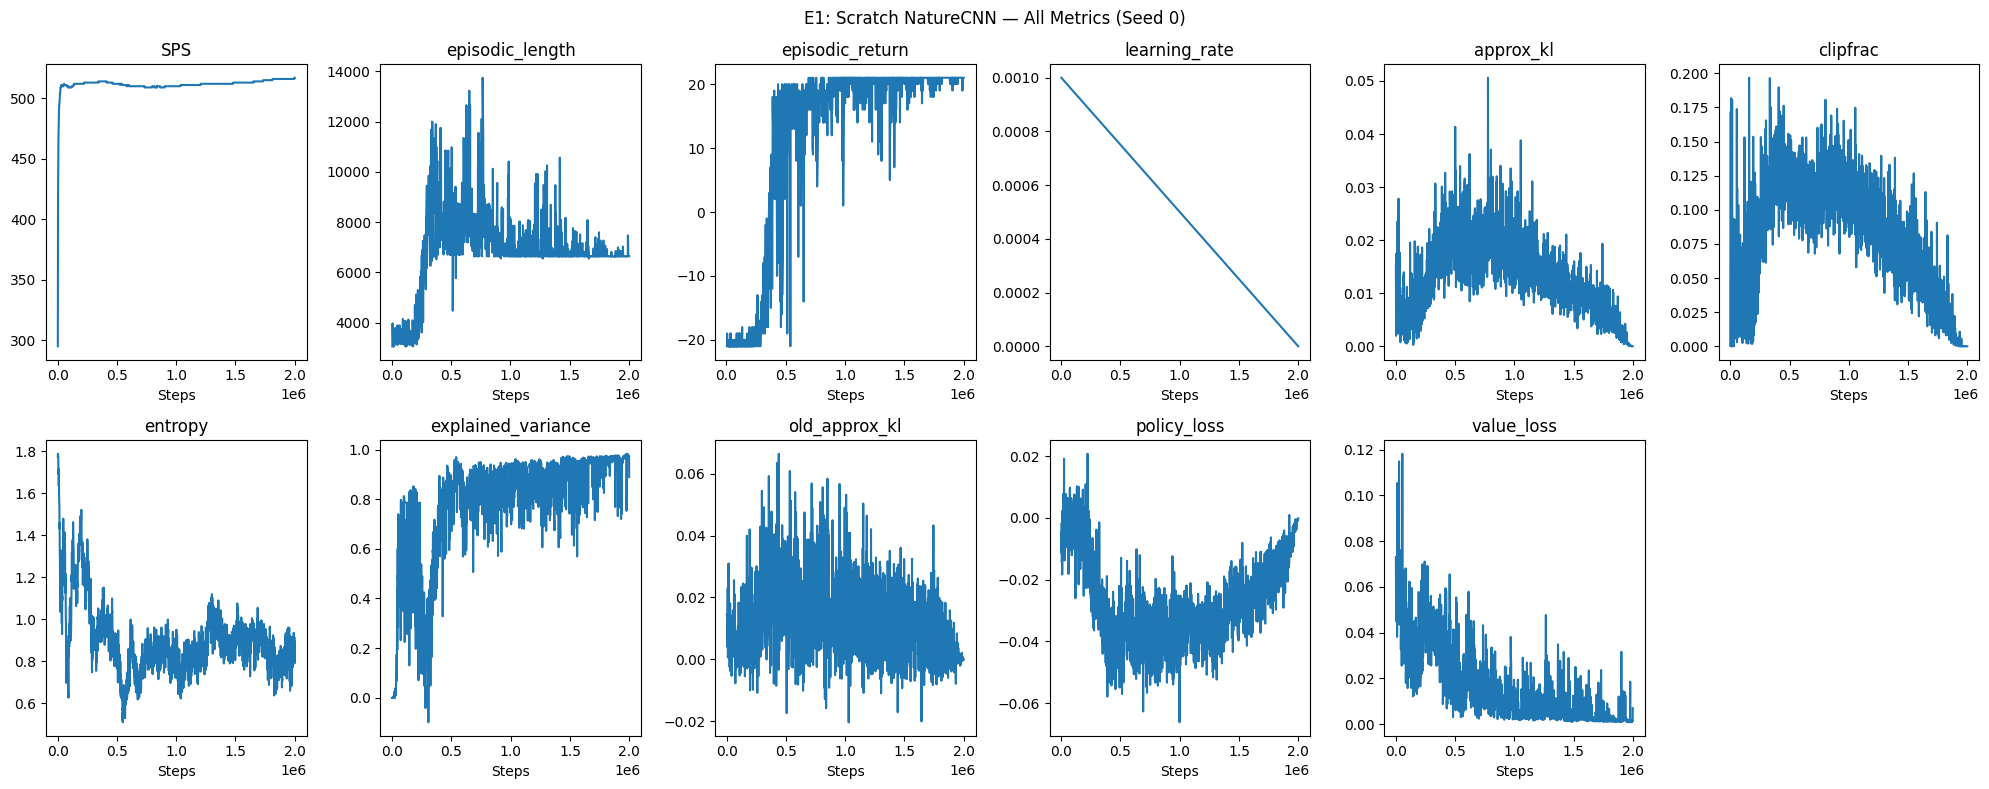

In [38]:
# Get all unique tags
tags = df['tag'].unique()
print(tags)

# Plot everything
n_tags = len(tags)
fig, axes = plt.subplots(2, (n_tags + 1) // 2, figsize=(20, 8))
axes = axes.flatten()

for i, tag in enumerate(tags):
    data = df[df['tag'] == tag]
    axes[i].plot(data['step'], data['value'])
    axes[i].set_title(tag.split('/')[-1])
    axes[i].set_xlabel('Steps')

# Hide empty subplots
for i in range(n_tags, len(axes)):
    axes[i].set_visible(False)

plt.suptitle('E1: Scratch NatureCNN — All Metrics (Seed 0)')
plt.tight_layout()
plt.savefig('e1_all_metrics.png', dpi=150)
plt.show()